<a href="https://colab.research.google.com/github/BrianBaik/LoanClassifier/blob/brian-dev/Sungmin_Baik_(Brian)_LoanClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# load your data
df = pd.read_csv("https://raw.githubusercontent.com/sziccardi/CSCI4521_DataRepository/refs/heads/main/Credit.csv")
df['Rating_Category'] = np.where(df['Rating'] > 670, 'Good', 'Poor')



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

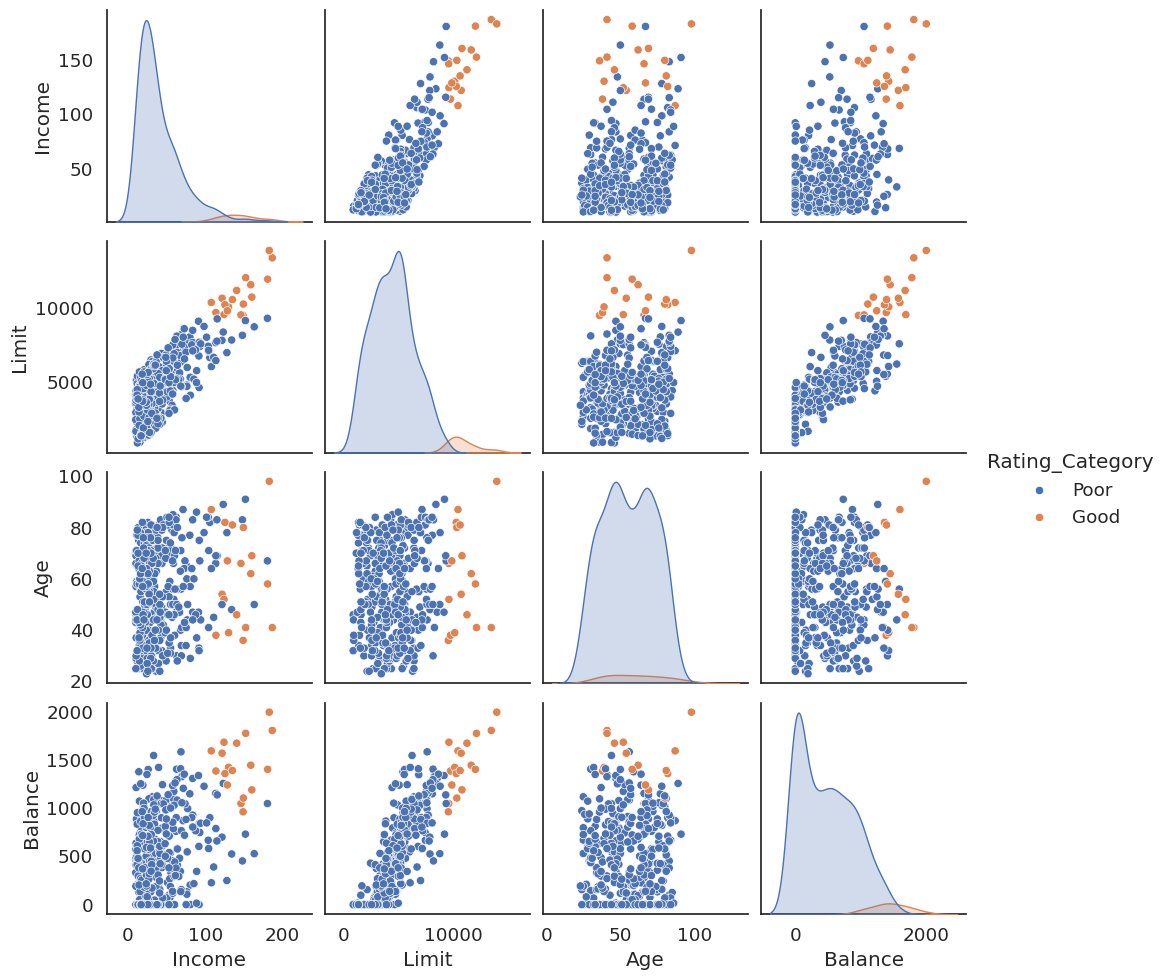

In [ ]:
features = ['Income', 'Limit', 'Age', 'Balance']
sns.pairplot(df, vars = features, hue='Rating_Category')
plt.show()

In [ ]:
def train_test_split(X,y,test_percent):
  numRows = y.size                     #number or rows in the entire dataset
  splitPoint = int((1-test_percent)*numRows)  #the row index test_size% of the way through
  p = np.random.permutation(numRows)   #array for shuffling data
  X = X[p]
  y = y[p]

  #Training data array
  X_train = X[:splitPoint]  # training features
  y_train = y[:splitPoint]  # training labels

  #Testing data array
  X_test = X[splitPoint:]  # testing features
  y_test = y[splitPoint:] # testing labels

  return X_train, X_test, y_train, y_test

In [ ]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [ ]:
def knn_accuracy(classify, X_train, y_train, X_test, y_test):
  pred_train = classify(X_train, y_train, X_train)
  pred_test = classify(X_train, y_train, X_test)

  train_metrics={
      'Training Precision': precision_score(y_train, pred_train, pos_label='Good', zero_division=0),
      'Training Recall': recall_score(y_train, pred_train, pos_label='Good', zero_division=0),
      'Training Accuracy': accuracy_score(y_train, pred_train),
      'Training F1-Score': f1_score(y_train, pred_train, pos_label='Good', zero_division=0)
  }

  test_metrics = {
      'Testing Precision': precision_score(y_test, pred_test, pos_label='Good', zero_division=0),
      'Testing Recall': recall_score(y_test, pred_test,pos_label='Good', zero_division=0),
      'Testing Accuracy': accuracy_score(y_test, pred_test),
      'Testing F1-Score': f1_score(y_test, pred_test, pos_label='Good', zero_division=0)
  }

  return train_metrics, test_metrics

In [ ]:
def knn_avg_accuracy(classifier, X, y, count=200, split=0.33):
    train_metrics = {'Training Precision': 0, 'Training Recall': 0, 'Training Accuracy': 0, 'Training F1-Score': 0}
    test_metrics = {'Testing Precision': 0, 'Testing Recall': 0, 'Testing Accuracy': 0, 'Testing F1-Score': 0}
    for _ in range(count):
        X_train, X_test, y_train, y_test = train_test_split(X, y, split)
        train_result, test_result = accuracy(classifier, X_train, y_train, X_test, y_test)
        for train_key, test_key in zip(train_metrics, test_metrics):
            train_metrics[train_key] += train_result[train_key]
            test_metrics[test_key] += test_result[test_key]

    for train_key, test_key in zip(train_metrics, test_metrics):
        train_metrics[train_key] /= count
        test_metrics[test_key] /= count

    return train_metrics, test_metrics

In [ ]:
from sklearn import neighbors
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
def knn_classifier(k):
    def knn_classify(x_train, y_train, x_test):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_train, y_train)

        pred = knn.predict(x_test)
        return pred
    return knn_classify

In [ ]:
X = df[features].to_numpy()
y = df['Rating_Category'].to_numpy()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, 0.33)
knn = knn_classifier(3)
knn_avg_accuracy(knn,X, y, count=200, split=0.33)

({'Training Precision': 0.9889079511175098,
  'Training Recall': 0.9777875249750249,
  'Training Accuracy': 0.9984888059701487,
  'Training F1-Score': 0.9825994883247836},
 {'Testing Precision': 0.95596626984127,
  'Testing Recall': 0.9156643217893219,
  'Testing Accuracy': 0.9945454545454571,
  'Testing F1-Score': 0.9274124415316365})

In [ ]:
def all_good_classifier(X_train, y_train, X_test):
  return np.full(X_test.shape[0], 'Good')


In [ ]:
def classifier_2_accuracy(classify, X_train, y_train, X_test, y_test):
    classifier2_pred_train = classify(X_train, y_train, X_train)
    classifier2_pred_test = classify(X_train, y_train, X_test)

    classifier2_train_metrics={
        'Training Precision': precision_score(y_train, classifier2_pred_train, pos_label='Good', zero_division=0),
        'Training Recall': recall_score(y_train, classifier2_pred_train, pos_label='Good', zero_division=0),
        'Training Accuracy': accuracy_score(y_train, classifier2_pred_train),
        'Training F1-Score': f1_score(y_train, classifier2_pred_train, pos_label='Good', zero_division=0)
    }

    classifier2_test_metrics = {
        'Testing Precision': precision_score(y_test, classifier2_pred_test, pos_label='Good', zero_division=0),
        'Testing Recall': recall_score(y_test, classifier2_pred_test,pos_label='Good', zero_division=0),
        'Testing Accuracy': accuracy_score(y_test, classifier2_pred_test),
        'Testing F1-Score': f1_score(y_test, classifier2_pred_test, pos_label='Good', zero_division=0)
    }

    return classifier2_train_metrics, classifier2_test_metrics

In [ ]:
def classifier_2_avg_accuracy(classifier, X, y, count=200, split=0.33):

    classifier2_train_metrics = {'Training Precision': 0, 'Training Recall': 0, 'Training Accuracy': 0, 'Training F1-Score': 0}
    classifier2_test_metrics = {'Testing Precision': 0, 'Testing Recall': 0, 'Testing Accuracy': 0, 'Testing F1-Score': 0}
    for _ in range(count):
        X_train, X_test, y_train, y_test = train_test_split(X, y, split)
        classifier2_train_result, classifier2_test_result = classifier_2_accuracy(classifier, X_train, y_train, X_test, y_test)

        for train_key, test_key in zip(classifier2_train_metrics, classifier2_test_metrics):
            classifier2_train_metrics[train_key] += classifier2_train_result[train_key]
            classifier2_test_metrics[test_key] += classifier2_test_result[test_key]

    for train_key, test_key in zip(classifier2_train_metrics, classifier2_test_metrics):
        classifier2_train_metrics[train_key] /= count
        classifier2_test_metrics[test_key] /= count

    return classifier2_train_metrics, classifier2_test_metrics

In [ ]:
classifier_2_avg_accuracy(all_good_classifier, X, y)

({'Training Precision': 0.04501865671641789,
  'Training Recall': 1.0,
  'Training Accuracy': 0.04501865671641789,
  'Training F1-Score': 0.08606986629946153},
 {'Testing Precision': 0.044962121212121245,
  'Testing Recall': 1.0,
  'Testing Accuracy': 0.044962121212121245,
  'Testing F1-Score': 0.08569040839079017})

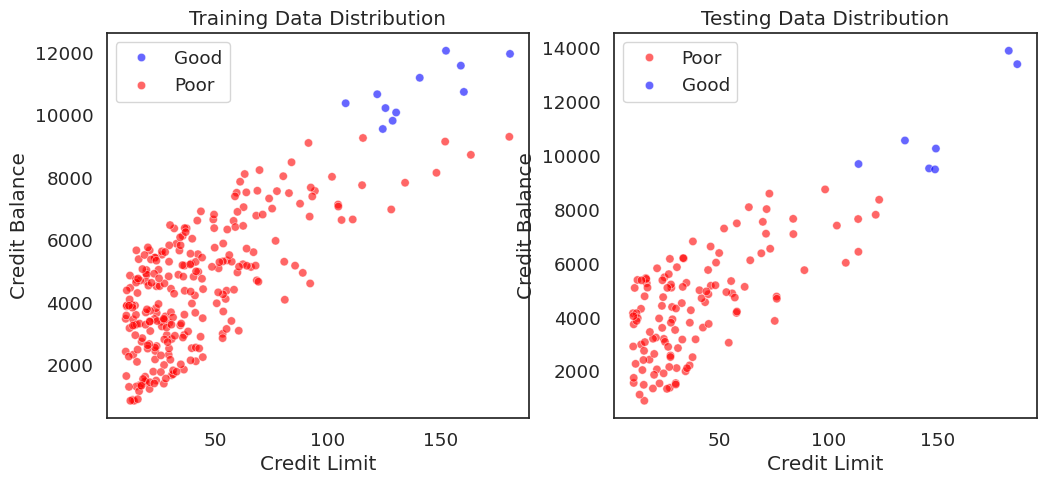

In [ ]:
knn = knn_classifier(3)
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=x_train[:,0], y=x_train[:,1], hue=y_train, palette={'Poor': 'red', 'Good': 'blue'}, alpha=0.6)
plt.title('Training Data Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Balance')

plt.subplot(1, 2, 2)
sns.scatterplot(x=x_test[:,0], y=x_test[:,1], hue=y_test, palette={'Poor': 'red', 'Good': 'blue'}, alpha=0.6) # Use x_test and y_test here
plt.title('Testing Data Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Balance')

plt.show()

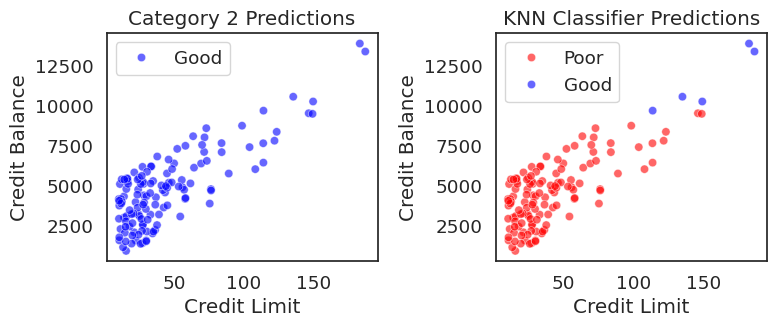

In [ ]:
# Baseline Classifier Predictions
plt.subplot(2, 2, 3)
baseline_pred = all_good_classifier(x_train, y_train, x_test)  # Use x_train and x_test
sns.scatterplot(x=x_test[:,0], y=x_test[:,1], hue=baseline_pred, palette={'Poor': 'red', 'Good': 'blue'}, alpha=0.6)  # Use x_test and correct palette
plt.title('Category 2 Predictions')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Balance')

# KNN Classifier Predictions
plt.subplot(2, 2, 4)
knn_pred = knn(x_train, y_train, x_test)  # Use x_train and x_test
sns.scatterplot(x=x_test[:,0], y=x_test[:,1], hue=knn_pred, palette={'Poor': 'red', 'Good': 'blue'}, alpha=0.6)  # Use x_test and correct palette
plt.title('KNN Classifier Predictions')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Balance')

plt.tight_layout()
plt.show()

In [ ]:
ks = np.arange(1,51)
test_acc_list = []
train_acc_list = []
for k_cur in ks:
    my_knn = knn_classifier(k_cur)
    test_acc = 0
    train_acc = 0
    for i in range(0,20):
        X_train, X_test, y_train, y_test = train_test_split(X,y,0.33)
        train_metrics, test_metrics = knn_accuracy(my_knn, X_train, y_train, X_test, y_test)
        test_acc += test_metrics['Testing Accuracy'] / 20

        train_metrics, test_metrics = knn_accuracy(my_knn, X_train, y_train, X_train, y_train)
        train_acc += train_metrics['Training Accuracy'] / 20
    test_acc_list.append(test_acc)
    train_acc_list.append(train_acc)

<Axes: xlabel='k', ylabel='value'>

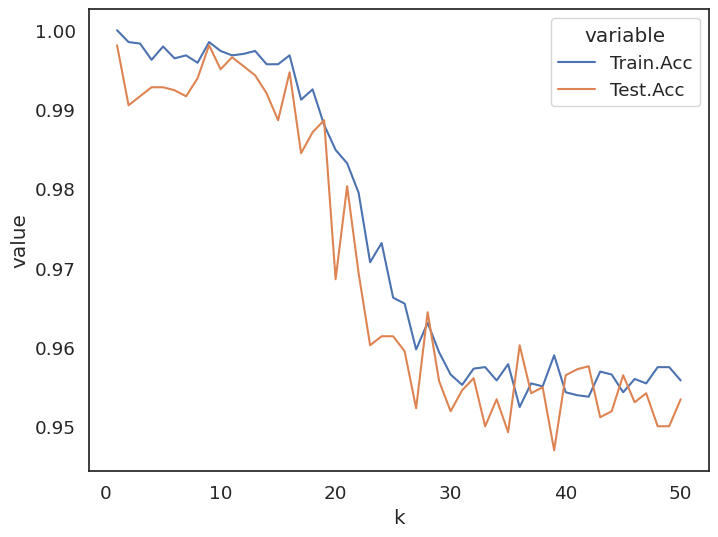

In [ ]:

from pylab import rcParams
sns.set(font_scale=1.2)
sns.set_style("white")

rcParams['figure.figsize'] = 8, 6
result = pd.DataFrame( {"k":ks,"Train.Acc":train_acc_list,"Test.Acc":test_acc_list} )
pd.melt(result, ['k'])
sns.lineplot(x="k",y="value", hue='variable', data=pd.melt(result, ['k']))